# Discovery cohort global analysis

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
  library(ggforce)
  library(patchwork)
  library(cowplot)
  library(ComplexHeatmap)
})

In [2]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [3]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/cite_seq/cohort_treatment_naive/annotated/annotated.qs", nthreads = getOption("hpc.ncpus", 1))

### totalVI denoised RNA and ADT data

In [ ]:
rna.denoised <- h5ad.to.seurat(
  file = "../data/processed/cite_seq/cohort_treatment_naive/models/totalvi/totalvi_rna_denoised.h5ad",
  x = "data",
  raw = NULL,
  assay.name = "RNA_denoised"
)

In [ ]:
adt.denoised <- h5ad.to.seurat(
  file = "../data/processed/cite_seq/cohort_treatment_naive/models/totalvi/totalvi_adt_denoised.h5ad",
  x = "data",
  raw = NULL,
  assay.name = "ADT_denoised"
)

In [7]:
seu[["RNA_denoised"]] <- rna.denoised[["RNA_denoised"]]
seu[["ADT_denoised"]] <- adt.denoised[["ADT_denoised"]]

In [8]:
seu

An object of class Seurat 
31865 features across 264512 samples within 5 assays 
Active assay: RNA (26424 features, 4993 variable features)
 3 layers present: data, counts, scale.data
 4 other assays present: ADT, ADTC, RNA_denoised, ADT_denoised
 5 dimensional reductions calculated: pca, integrated.rna, apca, integrated.adt, umap

### Perturbation scores

In [ ]:
meld.stats <- set_names(c("Early", "Late")) %>%
  map(
    .f = function(x) {
      read.table(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/meld_stats_{x}.tsv"),
        sep = "\t",
        header = TRUE
      )
    }
  )

### Program scores

In [ ]:
gep.usage <- set_names(c("B", "DC", "Mono", "NK", "T")) %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`


# Compute UMAP

In [14]:
seu <- RunUMAP(
  seu,
  reduction = "integrated.rna",
  dims = 1:50,
  metric = "cosine",
  n.neighbors = 30L,
  min.dist = 0.3,
  spread = 1,
  n.epochs = 200L,
  return.model = TRUE
)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
UMAP will return its model

18:11:23 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

18:11:23 Read 264512 rows and found 50 numeric columns

18:11:23 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

18:11:23 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:12

# Custom colour palettes

### Clusters

In [7]:
cluster.main.pal <- c(
  B = pals::brewer.reds(100)[90],
  DC = pals::brewer.greys(100)[90],
  Mono = pals::brewer.purples(100)[90],
  ILC = pals::brewer.oranges(100)[50],
  NK = pals::brewer.blues(100)[90],
  T = pals::brewer.greens(100)[90]
)

In [8]:
cluster.coarse.pal <- c(
  B_naive = pals::brewer.reds(5)[3],
  B_memory = pals::brewer.reds(5)[2],
  B_plasma = pals::brewer.reds(5)[4],
  DC_AXL_SIGLEC6 = pals::brewer.greys(5)[3],
  DC_conventional = pals::brewer.greys(5)[2],
  DC_plasmacytoid = pals::brewer.greys(5)[4],
  ILC = pals::brewer.oranges(100)[50],
  Mono_CD14 = pals::brewer.purples(5)[2],
  Mono_CD16 = pals::brewer.purples(5)[4],
  NK_CD56dim = pals::brewer.blues(5)[4],
  NK_CD56bright = pals::brewer.blues(5)[2],
  T_CD4_naive = pals::brewer.greens(10)[2],
  T_CD4_memory = pals::brewer.greens(10)[7],
  T_regulatory_naive = pals::brewer.greens(10)[5],
  T_regulatory_memory = pals::brewer.greens(10)[9],
  T_CD8_naive = pals::brewer.greens(10)[10],
  T_CD8_memory = pals::brewer.greens(10)[6],
  T_MAIT = pals::brewer.greens(10)[4],
  T_GD = pals::brewer.greens(10)[8],
  T_DN = pals::brewer.greens(10)[3]
)

In [9]:
cluster.pal <- c(cluster.main.pal, cluster.coarse.pal)

# Donor metadata

In [ ]:
donor.metadata <- read.table(
  file = "../data/metadata/donor_metadata.tsv",
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
) %>%
  mutate(
    sex = factor(sex, levels = c("F", "M")),
    disease_type = factor(disease_type, levels = c("RR_high", "RR_low", "PP")),
    infusion_1_date = ymd(infusion_1_date)
  )

In [ ]:
donor.metadata

donor_id,age,sex,bmi,disease_type,disease_duration,relapses_last_2_yr,relapses_last_yr,last_relapse_interval,mri_baseline_activity,relapses_on_ocrelizumab,mri_on_ocrelizumab_activity,edss_edmus,treatment_naive,prior_dmt,infusion_1_date,infusion_2_interval,infusion_3_interval,infusion_4_interval,infusion_5_interval
<chr>,<int>,<fct>,<dbl>,<fct>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<lgl>,<lgl>,<date>,<int>,<int>,<int>,<int>
OCRZ003,19,M,26.61,RR_high,0,4,4,4,new,0,none,1.0,TRUE,NA,2019-06-26,14,189,303,263
OCRZ004,24,F,22.48,RR_high,1,2,2,1,new,0,none,1.5,TRUE,NA,2019-07-10,14,226,259,252
OCRZ011,39,M,23.71,RR_low,0,1,1,4,enhancing,0,none,1.0,TRUE,NA,2019-09-11,14,405,483,427
OCRZ012,46,F,32.66,RR_high,1,6,2,9,none,0,none,6.0,TRUE,NA,2019-09-18,14,156,287,270
OCRZ013,44,F,26.78,RR_high,0,3,2,4,none,0,none,5.0,TRUE,NA,2019-10-02,14,307,343,322
OCRZ014,47,F,25.48,RR_high,1,4,3,8,enhancing,0,none,5.0,TRUE,NA,2019-11-06,14,328,290,270
OCRZ019,61,F,28.83,PP,2,0,0,NA,enhancing,0,none,6.0,TRUE,NA,2020-01-14,15,202,287,409
OCRZ020,24,F,23.83,RR_low,1,2,1,12,none,0,none,3.0,TRUE,NA,2020-01-07,14,308,385,280
OCRZ022,60,M,24.81,PP,3,0,0,NA,new,0,none,6.0,TRUE,NA,2020-01-29,14,202,231,245


# Visualise integration

Inferred data type as 'discrete'. To override, set type explicitly.



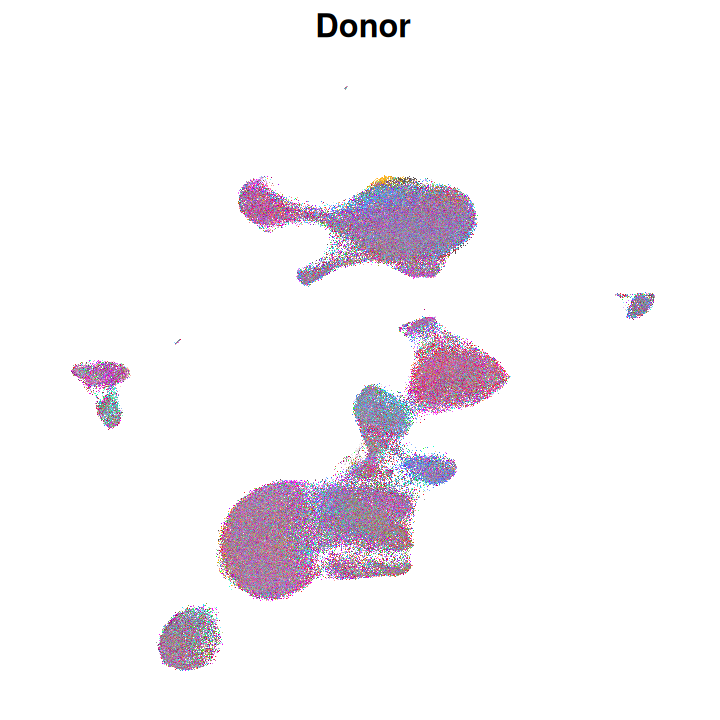

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

plot <- embedding.plot(
  seu,
  colour = "donor",
  cmap = pals::polychrome(14) |> set_names(sort(unique(seu$donor))),
  labs = list(title = "Donor"), 
  show.legend = FALSE,
  rasterise = TRUE,
  size.adj = 2,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/cohort_treatment_naive_all_donor_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



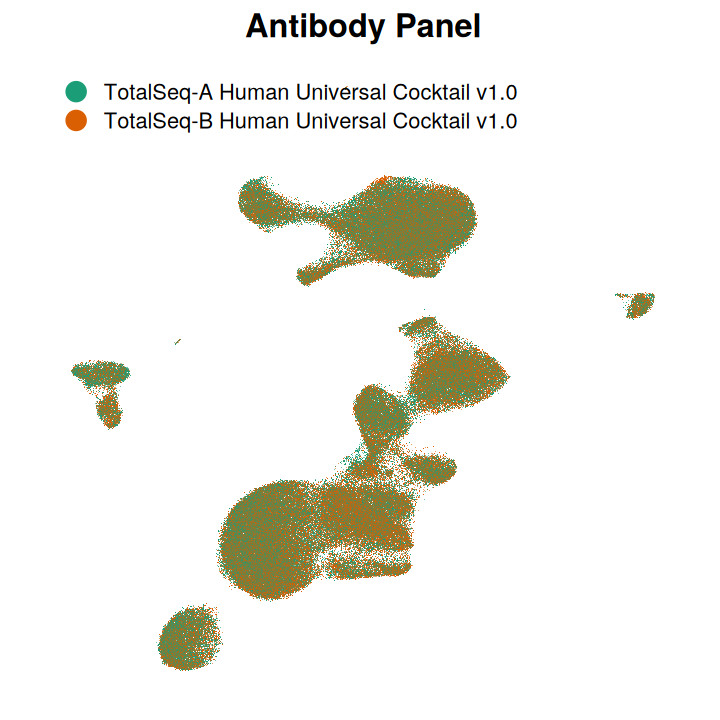

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

plot <- embedding.plot(
  seu,
  colour = "adt_panel",
  cmap = pals::brewer.dark2(3)[1:2] |> set_names(sort(unique(seu$adt_panel))),
  labs = list(title = "Antibody Panel", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 2,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), ncol = 1)) +
  inset.legend(location = "topleft") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/cohort_treatment_naive_all_adt_panel_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise cell types

Warning message:
"There were 5 warnings in `reframe()`.
The first warning was:
i In argument: `{ ... }`.
i In group 3: `cluster_coarse = B_plasma`.
Caused by warning in `KernSmooth::bkde2D()`:
! Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'
i Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings."
Inferred data type as 'discrete'. To override, set type explicitly.



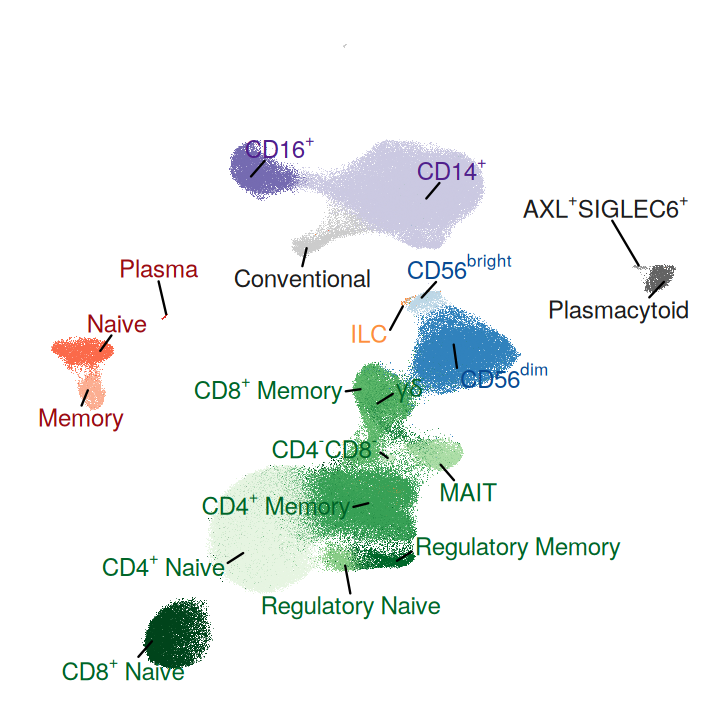

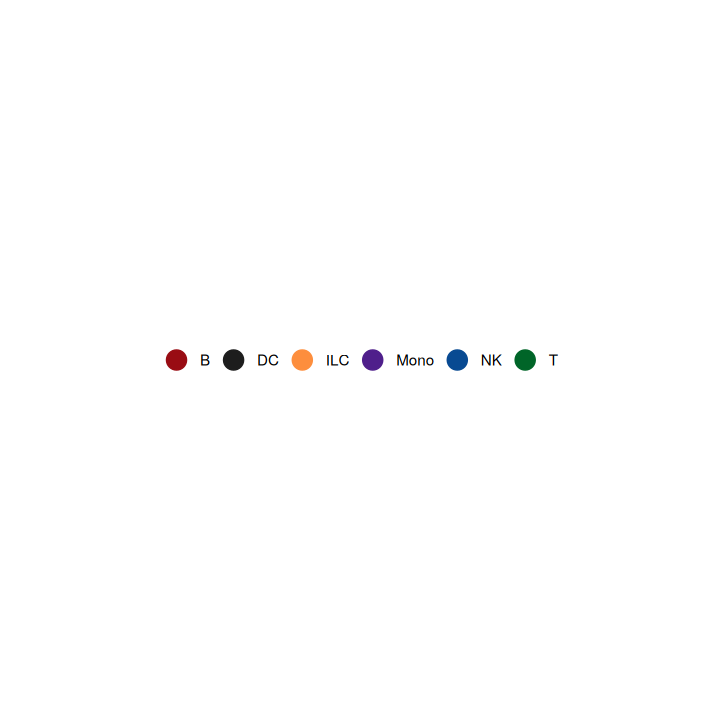

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "cluster_coarse", "cluster_main"))
labels <- data %>%
  group_by(cluster_coarse) %>%
  summarise(cluster_main = first(cluster_main)) %>%
  left_join(calculate.centroid.density(data, group.var = "cluster_coarse", x.var = "umap_1", y.var = "umap_2"), by = "cluster_coarse") %>%
  mutate(
    cluster_coarse = case_match(
      cluster_coarse,
      "B_naive" ~ "Naive",
      "B_memory" ~ "Memory",
      "B_plasma" ~ "Plasma",
      "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
      "DC_conventional" ~ "Conventional",
      "DC_plasmacytoid" ~ "Plasmacytoid",
      "ILC" ~ "ILC",
      "Mono_CD14" ~ "CD14^'+'",
      "Mono_CD16" ~ "CD16^'+'",
      "NK_CD56dim" ~ "CD56^dim",
      "NK_CD56bright" ~ "CD56^bright",
      "T_CD4_naive" ~ "CD4^'+'~Naive",
      "T_CD4_memory" ~ "CD4^'+'~Memory",
      "T_regulatory_naive" ~ "Regulatory~Naive",
      "T_regulatory_memory" ~ "Regulatory~Memory",
      "T_CD8_naive" ~ "CD8^'+'~Naive",
      "T_CD8_memory" ~ "CD8^'+'~Memory",
      "T_MAIT" ~ "MAIT",
      "T_GD" ~ "gamma*delta",
      "T_DN" ~ "CD4^'-'*CD8^'-'"
    )
  )

plot <- embedding.plot(data, colour = "cluster_coarse", cmap = cluster.pal, show.legend = FALSE, rasterise = TRUE, size.adj = 2, alpha = 1, pixels = c(2048, 2048)) +
  ggrepel::geom_text_repel(
    data = labels,
    mapping = aes(x = x, y = y, colour = cluster_main, label = cluster_coarse),
    segment.colour = "black",
    box.padding = 0.75,
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0,
    seed = 42,
    parse = TRUE,
    show.legend = FALSE
  ) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank()
  )

legend <- ggplot(data = data, mapping = aes(x = umap_1, y = umap_2, colour = cluster_main)) +
  geom_point() +
  scale_colour_manual(values = cluster.pal) +
  labs(colour = NULL) +
  theme_void() +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 1))

legend <- ggpubr::get_legend(legend)

plot

ggdraw(legend)

ggsave(
  plot = plot,
  filename = "../results/plots/cohort_treatment_naive_all_cell_type_umap.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

ggsave(
  plot = legend,
  filename = "../results/plots/cell_type_umap_legend.pdf",
  width = 6,
  height = 0.5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise gene markers

In [24]:
p <- expression.plot(
  seu,
  features = c(
    "CD3D", "CD4", "CD8A", "CD19",
    "NCAM1", "FCGR3A", "LYZ", "IL3RA"
  ),
  limits = c(NA, "p99"),
  cmap = pals::plasma(100),
  assay = "RNA_denoised",
  verbose = FALSE,
  rasterise = TRUE,
  size.adj = 2,
  alpha = 1,
  pixels = c(2048, 2048)
) %>%
  lapply(
    function(x) {
      x +
        theme(
          axis.title = element_blank(),
          panel.border = element_blank(),
          plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
          legend.position = "none"
        )
    }
  )

p[[length(p)]] <- p[[length(p)]] +
  guides(colour = guide_colourbar(title = "Expression", direction = "horizontal", barwidth = 5, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)) +
  inset.legend(location = "bottomright") +
  theme(
    legend.title.position = "top",
    legend.text.position = "bottom",
    legend.title = element_text(face = "bold", size = 12, hjust = 0),
    legend.text = element_blank()
  )

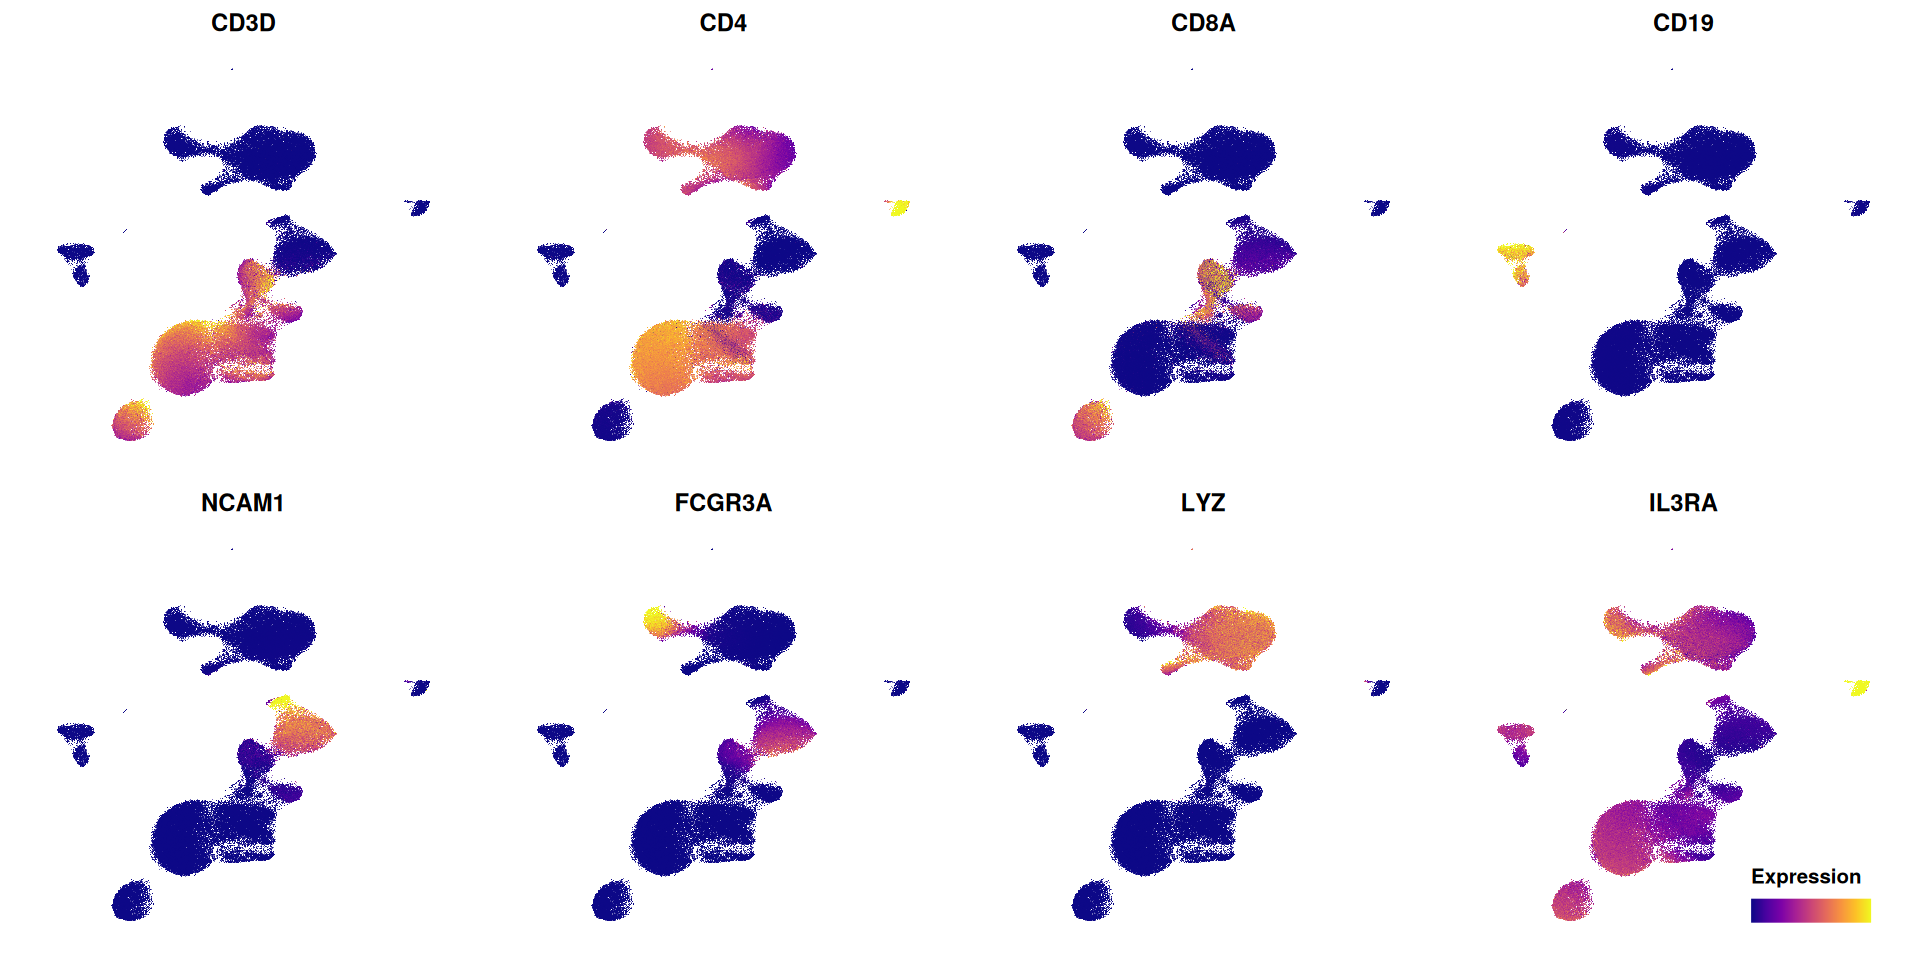

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 8)

final.plot <- cowplot::plot_grid(plotlist = p, ncol = 4)

final.plot

ggsave(
  filename = "../results/plots/cohort_treatment_naive_all_marker_genes_umap.pdf",
  plot = final.plot,
  width = 16,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise protein markers

In [25]:
p <- expression.plot(
  seu,
  features = c(
    "ADT-CD3", "ADT-CD4", "ADT-CD8", "ADT-CD25",
    "ADT-CD45RA", "ADT-CD45RO", "ADT-TCR.Va7.2", "ADT-TCR.Vd2",
    "ADT-CD14", "ADT-CD16", "ADT-CD56", "ADT-CD161",
    "ADT-CD19", "ADT-IgD", "ADT-CD11c", "ADT-CD123"
  ),
  limits = c(NA, "p99"),
  cmap = pals::magma(100),
  assay = "ADT_denoised",
  verbose = FALSE,
  show.legend = FALSE,
  rasterise = FALSE,
  alpha = 0.1
) %>%
  lapply(
    function(x) {
      x +
        theme(
          axis.title = element_blank(),
          panel.border = element_blank(),
          plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
        )
    }
  )

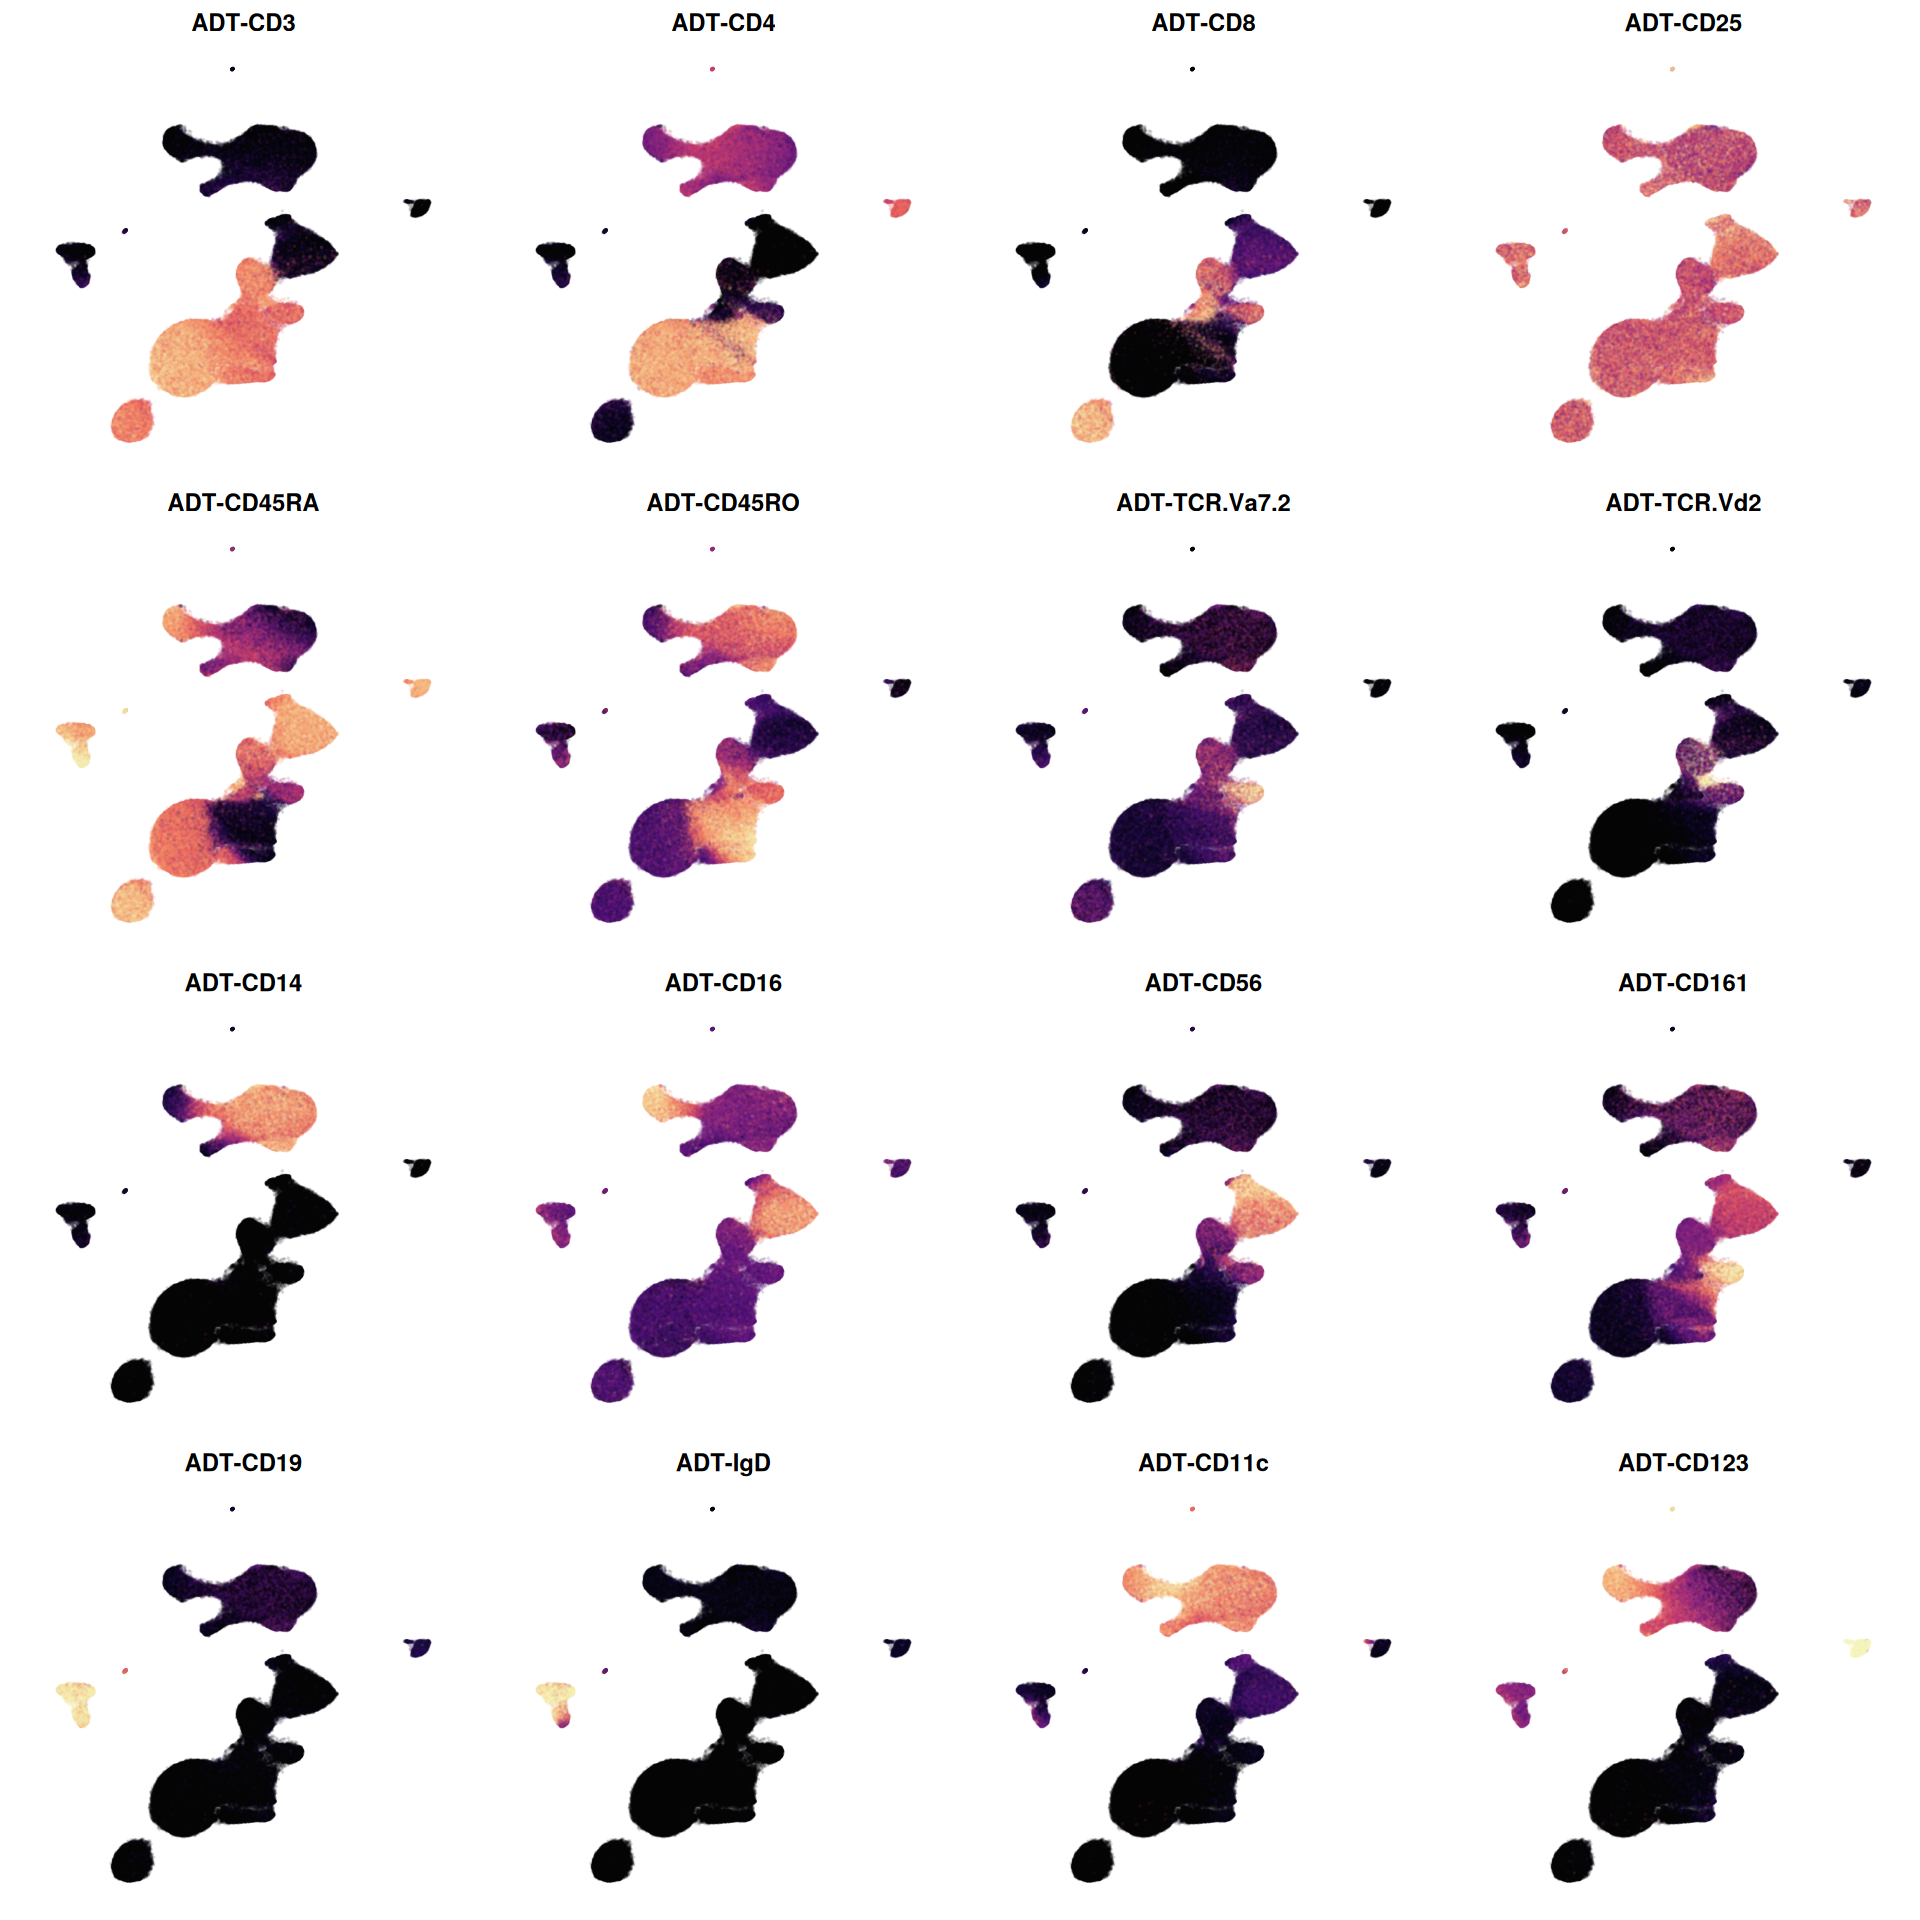

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 16)

final.plot <- cowplot::plot_grid(plotlist = p, ncol = 4)

final.plot

ggsave(
  filename = "../results/plots/cohort_treatment_naive_all_marker_proteins_umap.pdf",
  plot = final.plot,
  width = 16,
  height = 16,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Warning message:
"Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`)."


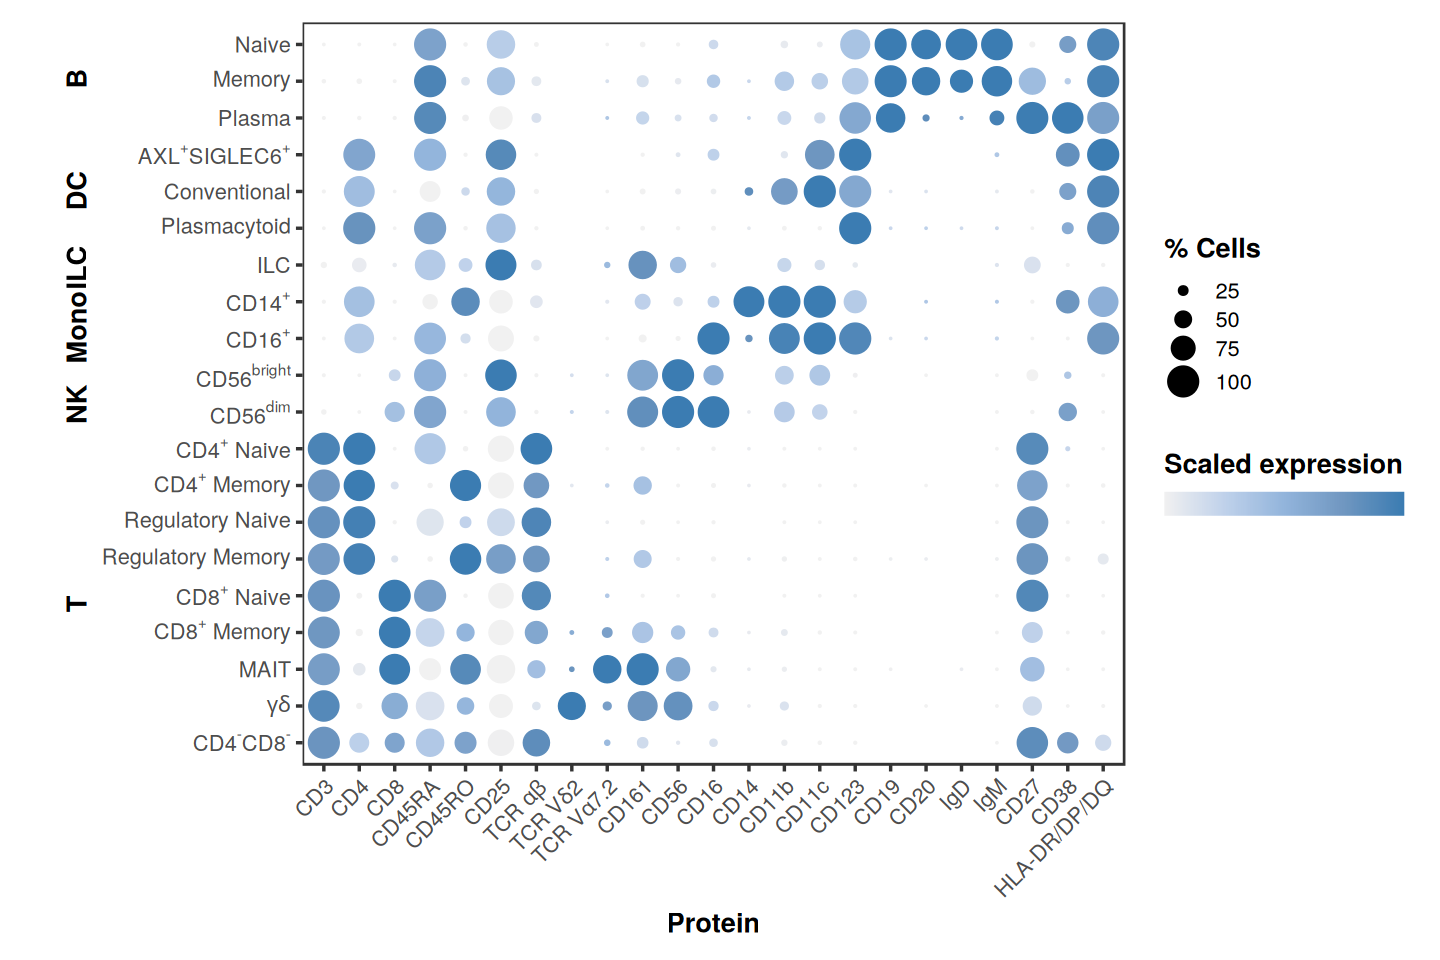

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

chosen.features <- c(
  "ADT-CD3", "ADT-CD4", "ADT-CD8", "ADT-CD45RA", "ADT-CD45RO", "ADT-CD25",
  "ADT-TCR.AB", "ADT-TCR.Vd2", "ADT-TCR.Va7.2", "ADT-CD161", "ADT-CD56", "ADT-CD16",
  "ADT-CD14", "ADT-CD11b", "ADT-CD11c", "ADT-CD123", "ADT-CD19", "ADT-CD20",
  "ADT-IgD", "ADT-IgM", "ADT-CD27", "ADT-CD38", "ADT-HLA.DR.DP.DQ"
)

annotation <- ggplot(data = seu[[c("cluster_main", "cluster_coarse")]] %>% distinct(), mapping = aes(y = fct_rev(cluster_coarse))) +
  facet_grid(rows = vars(cluster_main), scales = "free", space = "free") +
  theme_void() +
  theme(
    strip.text.y = element_text(size = 16, face = "bold", angle = 90),
    panel.spacing = unit(0, "cm")
  )

plot <- dot.plot(
  seu,
  assay = "ADT_denoised",
  features = chosen.features,
  thresholds = c(
    "ADT-CD3" = 1.5,
    "ADT-CD4" = 1,
    "ADT-CD8" = 1,
    "ADT-CD45RA" = 2,
    "ADT-CD45RO" = 2,
    "ADT-CD25" = 0.1,
    "ADT-TCR.AB" = 1,
    "ADT-TCR.Vd2" = 2,
    "ADT-TCR.Va7.2" = 1,
    "ADT-CD161" = 1,
    "ADT-CD56" = 1,
    "ADT-CD16" = 2,
    "ADT-CD14" = 1.5,
    "ADT-CD11b" = 0.5,
    "ADT-CD11c" = 1,
    "ADT-CD123" = 1,
    "ADT-CD19" = 2,
    "ADT-CD20" = 3,
    "ADT-IgD" = 2,
    "ADT-IgM" = 3,
    "ADT-CD27" = 1,
    "ADT-CD38" = 3,
    "ADT-HLA.DR.DP.DQ" = 2
  ),
  min.pct = 0.01,
  max.size = 8,
  cluster = FALSE,
  limits = c(" " = -0.5, " " = 1.5),
  labs = list(x = "Protein", y = NULL)
) +
  scale_x_discrete(
    labels = function(x) {
      gsub(pattern = "^ADT-", replacement = "", x = x) %>%
        case_match(
          .,
          "TCR.AB" ~ "TCR~alpha*beta",
          "TCR.Vd2" ~ "TCR~V*delta*2",
          "TCR.Va7.2" ~ "TCR~V*alpha*7.2",
          "HLA.DR.DP.DQ" ~ "'HLA-DR/DP/DQ'",
          .default = .
        ) %>%
        parse(text = .)
    }
  ) +
  scale_y_discrete(
    labels = function(x) {
      case_match(
        x,
        "B_naive" ~ "Naive",
        "B_memory" ~ "Memory",
        "B_plasma" ~ "Plasma",
        "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
        "DC_conventional" ~ "Conventional",
        "DC_plasmacytoid" ~ "Plasmacytoid",
        "ILC" ~ "ILC",
        "Mono_CD14" ~ "CD14^'+'",
        "Mono_CD16" ~ "CD16^'+'",
        "NK_CD56dim" ~ "CD56^dim",
        "NK_CD56bright" ~ "CD56^bright",
        "T_CD4_naive" ~ "CD4^'+'~Naive",
        "T_CD4_memory" ~ "CD4^'+'~Memory",
        "T_regulatory_naive" ~ "Regulatory~Naive",
        "T_regulatory_memory" ~ "Regulatory~Memory",
        "T_CD8_naive" ~ "CD8^'+'~Naive",
        "T_CD8_memory" ~ "CD8^'+'~Memory",
        "T_MAIT" ~ "MAIT",
        "T_GD" ~ "gamma*delta",
        "T_DN" ~ "CD4^'-'*CD8^'-'"
      ) %>%
        parse(text = .)
    }
  ) +
  guides(
    size = guide_legend(order = 1),
    color = guide_colorbar(order = 2, direction = "horizontal", title.position = "top", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)
  ) +
  theme(
    axis.title = element_text(face = "bold"),
    legend.title = element_text(vjust = 1, face = "bold"),
  )

final.plot <- annotation + plot + plot_layout(widths = c(2, 30))

final.plot

ggsave(
  plot = final.plot,
  filename = "../results/plots/cohort_treatment_naive_all_marker_proteins_dotplot.pdf",
  width = 12,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise cell type hierarchy

In [47]:
data <- FetchData(seu, vars = c("cluster_main", "cluster_coarse", "cluster_fine")) %>%
  group_by(cluster_main, cluster_coarse, cluster_fine) %>%
  summarise(count = n()) %>%
  gather_set_data(1:3) %>%
  mutate(
    y = factor(y, levels = c(
      "B",
      "B_naive_transitional", "B_naive", "B_memory", "B_plasma",
      "DC",
      "DC_AXL_SIGLEC6", "DC_conventional", "DC_conventional_1", "DC_conventional_2", "DC_plasmacytoid",
      "ILC",
      "Mono",
      "Mono_CD14", "Mono_CD14_platelet", "Mono_CD14_IL1B", "Mono_CD14_IFN", "Mono_CD14_CD16", "Mono_CD16", "Mono_CD16_IFN",
      "NK",
      "NK_CD56bright", "NK_CD56dim",
      "T",
      "T_CD4_naive", "T_CD4_naive_SOX4", "T_CD4_naive_IFN", "T_CD4_memory", "T_CD4_memory_central", "T_CD4_memory_central_IFN", "T_CD4_memory_effector",
      "T_regulatory_naive", "T_regulatory_memory",
      "T_CD8_naive", "T_CD8_naive_SOX4", "T_CD8_naive_IFN", "T_CD8_memory", "T_CD8_memory_central", "T_CD8_memory_effector",
      "T_MAIT", "T_GD", "T_DN"
    ))
  )

`summarise()` has grouped output by 'cluster_main', 'cluster_coarse'. You can
override using the `.groups` argument.


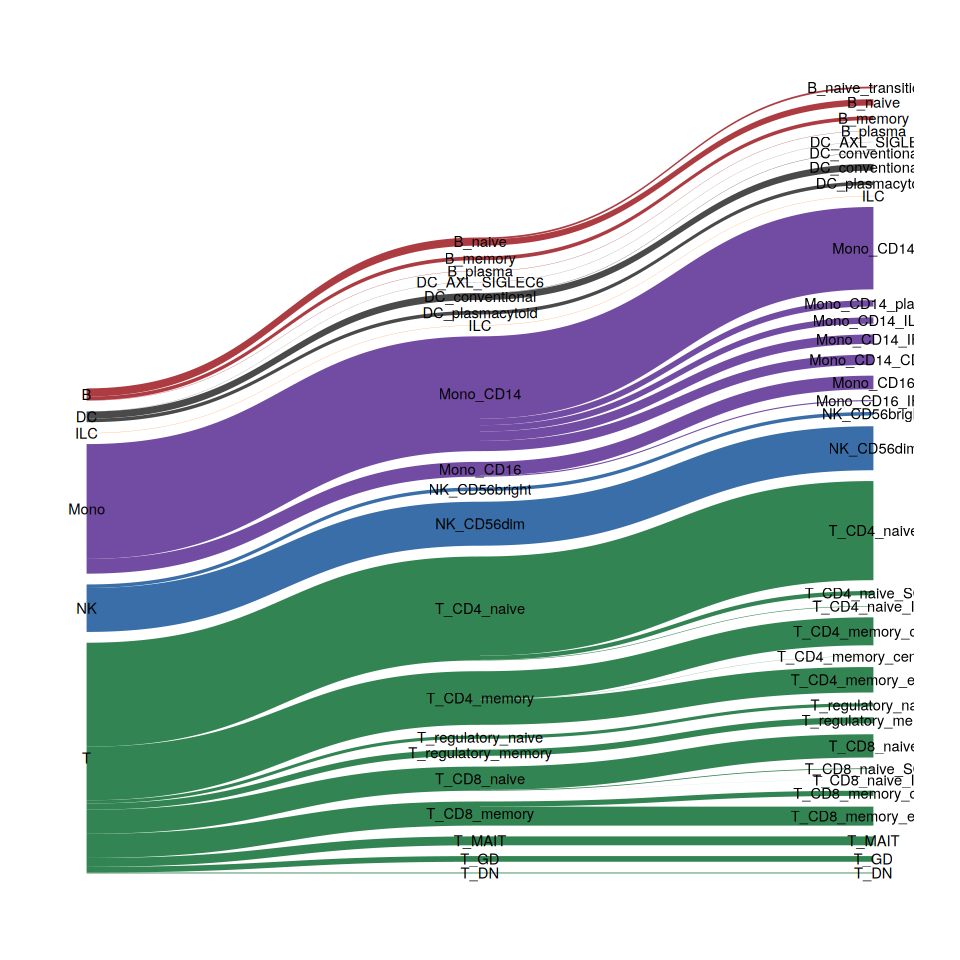

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 8)

plot <- ggplot(data = data, mapping = aes(x = x, id = id, split = y, value = count)) +
  geom_parallel_sets(aes(fill = cluster_main), alpha = 0.8, axis.width = 0, sep = 0.025) +
  geom_parallel_sets_labels(colour = "black", size = 3, angle = 360, sep = 0.025) +
  scale_fill_manual(values = cluster.pal) +
  labs(x = NULL) +
  theme_void() +
  theme(
    legend.position = "none",
    plot.margin = margin(1, 1, 1, 1, unit = "cm")
  )

plot

ggsave(
  filename = "../results/plots/cohort_treatment_naive_all_cell_type_parallel_sets.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise perturbation effects of treatment

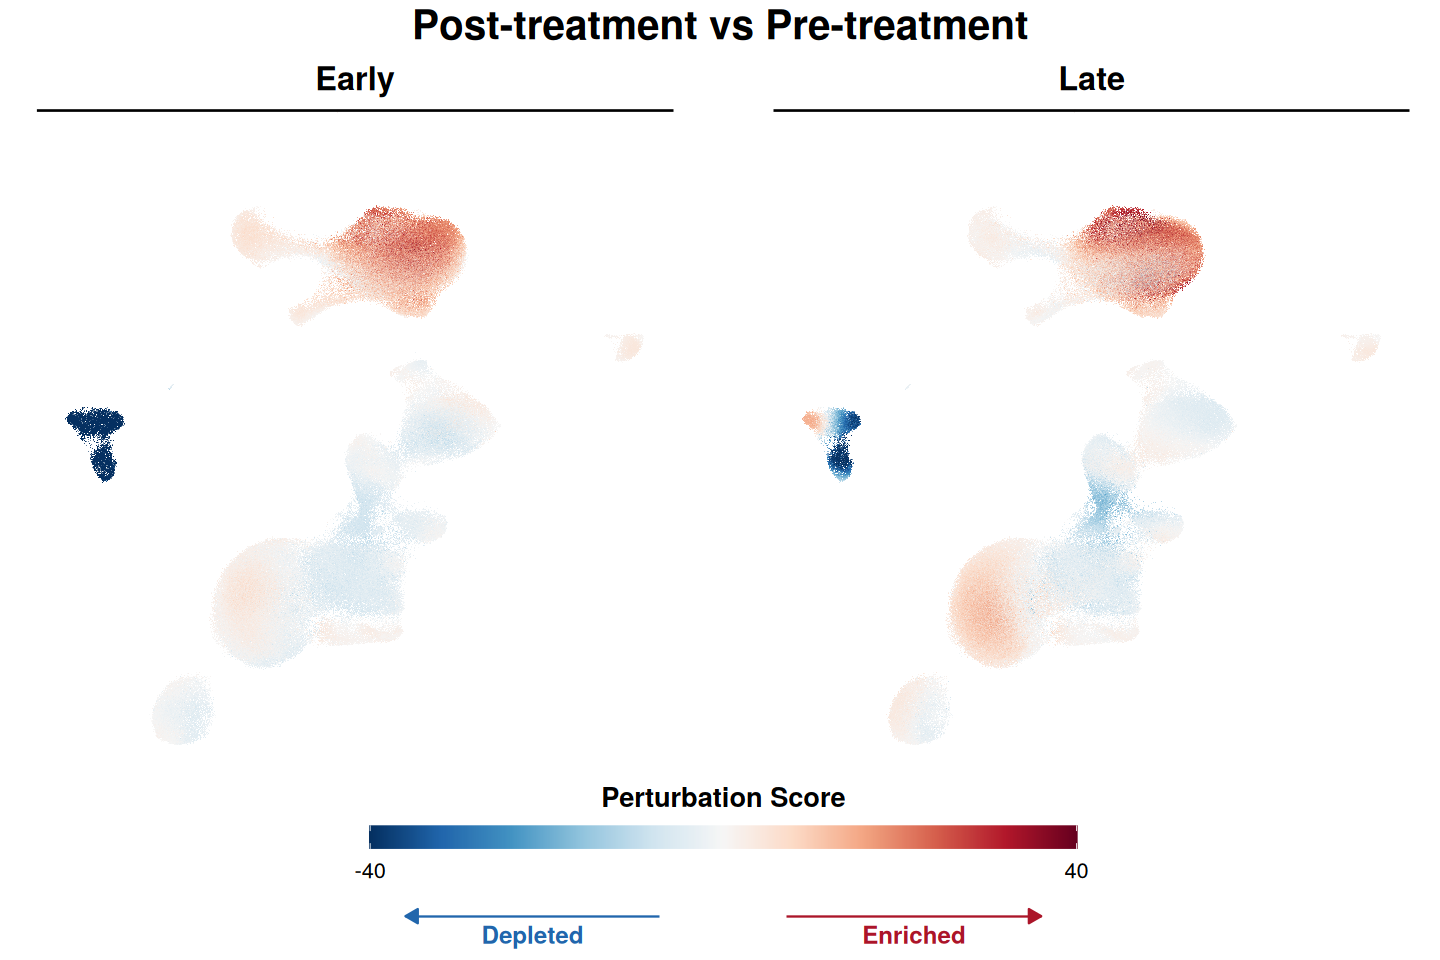

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

cond <- c("Early", "Late")
plots <- set_names(cond) %>%
  map(
    .f = function(x, data, stats) {
      data <- data %>%
        bind_cols(stats[[x]][rownames(data), ])
      p <- embedding.plot(
        data,
        colour = "z",
        cmap = rev(pals::brewer.rdbu(100)),
        type = "diverging",
        limits = c(-40, 40),
        breaks = c(-40, 40),
        labs = list(title = x, colour = "Perturbation Score"),
        verbose = FALSE,
        rasterise = TRUE,
        size.adj = 2,
        alpha = 1,
        pixels = c(2048, 2048)
      ) +
        scale_y_continuous(expand = c(0, 0)) +
        annotate(
          "segment",
          x = -Inf, xend = Inf,
          y = Inf, yend = Inf,
          colour = "black",
          size = 1,
          linetype = 1
        ) +
        theme(
          panel.border = element_blank(),
          axis.title = element_blank(),
          plot.title = element_text(face = "bold", hjust = 0.5),
          legend.position = "none",
          plot.margin = margin(5, 5, 5, 5, "pt")
        )

      return(p)
    },
    data = FetchData(seu, vars = c("umap_1", "umap_2")),
    stats = meld.stats
  )

annotation.arrow <- ggplot() +
  geom_segment(aes(x = 0.45, xend = 0.25, y = 0.7, yend = 0.7), 
               arrow = arrow(length = unit(0.3, "cm"), type = "closed"), 
               linewidth = 0.5, color = pals::brewer.rdbu(100)[90]) +
  geom_segment(aes(x = 0.55, xend = 0.75, y = 0.7, yend = 0.7), 
               arrow = arrow(length = unit(0.3, "cm"), type = "closed"), 
               linewidth = 0.5, color = pals::brewer.rdbu(100)[10]) +
  geom_text(aes(x = 0.35, y = 0.3, label = "Depleted"), 
            hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[90], fontface = "bold") +
  geom_text(aes(x = 0.65, y = 0.3, label = "Enriched"), 
            hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[10], fontface = "bold") +
  xlim(0, 1) + ylim(0, 1) +
  theme_void()

plot.combined <- (plots[["Early"]] | plot_spacer() | plots[["Late"]]) +
  plot_layout(widths = c(1, 0.05, 1), guides = "collect") &
  theme(
    legend.position = "bottom",
    legend.title.position = "top",
    legend.direction = "horizontal",
    legend.title = element_text(vjust = 1, face = "bold", hjust = 0.5),
    legend.key.width = unit(3, "cm"),
    legend.key.height = unit(0.5, "cm"),
    legend.margin = margin(t = 10, b = 5)
  )

final.plot <- plot.combined / annotation.arrow + 
  plot_layout(heights = c(10, 0.8)) +
  plot_annotation(
    title = "Post-treatment vs Pre-treatment",
    theme = theme(
      plot.title = element_text(size = 24, face = "bold", hjust = 0.5)
    )
  )

final.plot

ggsave(
  plot = final.plot,
  filename = "../results/plots/cohort_treatment_naive_all_perturbation_scores_umap.pdf",
  width = 12,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

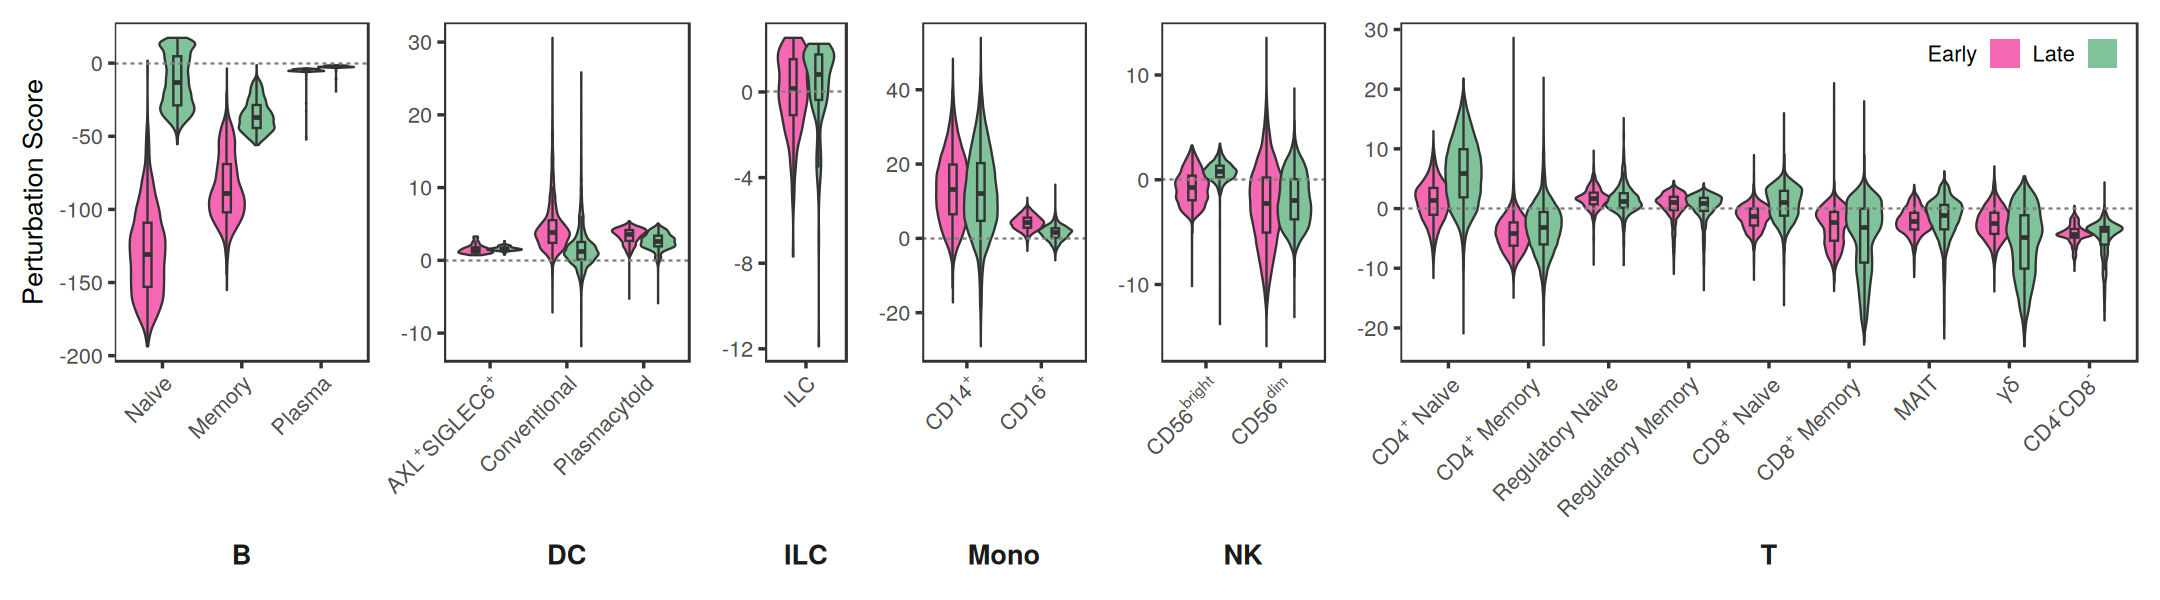

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 5)

cond <- c("Early", "Late")
data.combined <- map_dfr(cond, function(x) {
  FetchData(seu, vars = c("cluster_main", "cluster_coarse")) %>%
    bind_cols(meld.stats[[x]]) %>%
    mutate(condition = x)
}) %>%
  bind_rows() %>%
  mutate(
    cluster_coarse = factor(
      case_match(
        cluster_coarse,
        "B_naive" ~ "Naive",
        "B_memory" ~ "Memory",
        "B_plasma" ~ "Plasma",
        "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
        "DC_conventional" ~ "Conventional",
        "DC_plasmacytoid" ~ "Plasmacytoid",
        "ILC" ~ "ILC",
        "Mono_CD14" ~ "CD14^'+'",
        "Mono_CD16" ~ "CD16^'+'",
        "NK_CD56bright" ~ "CD56^bright",
        "NK_CD56dim" ~ "CD56^dim",
        "T_CD4_naive" ~ "CD4^'+'~Naive",
        "T_CD4_memory" ~ "CD4^'+'~Memory",
        "T_regulatory_naive" ~ "Regulatory~Naive",
        "T_regulatory_memory" ~ "Regulatory~Memory",
        "T_CD8_naive" ~ "CD8^'+'~Naive",
        "T_CD8_memory" ~ "CD8^'+'~Memory",
        "T_MAIT" ~ "MAIT",
        "T_GD" ~ "gamma*delta",
        "T_DN" ~ "CD4^'-'*CD8^'-'"
      ),
      levels = c(
        "Naive", "Memory", "Plasma",
        "AXL^'+'*SIGLEC6^'+'", "Conventional", "Plasmacytoid",
        "ILC",
        "CD14^'+'", "CD16^'+'",
        "CD56^bright", "CD56^dim",
        "CD4^'+'~Naive", "CD4^'+'~Memory", "Regulatory~Naive", "Regulatory~Memory",
        "CD8^'+'~Naive", "CD8^'+'~Memory", "MAIT", "gamma*delta", "CD4^'-'*CD8^'-'"
      )
    )
  )

plots <- map(
  c("B", "DC", "ILC", "Mono", "NK", "T"),
  function(x, data = data.combined) {
    ggplot(
      data = filter(data, cluster_main == x),
      mapping = aes(x = cluster_coarse, y = z, fill = condition)
    ) +
      geom_violin(scale = "width", position = position_dodge(width = 0.75), show.legend = FALSE) +
      geom_boxplot(width = 0.2, outlier.shape = NA, position = position_dodge(width = 0.75), key_glyph = "rect") +
      geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
      facet_wrap(~ cluster_main, strip.position = "bottom") +
      labs(
        title = NULL,
        x = NULL,
        y = if (x == "B") "Perturbation Score" else NULL,
        fill = NULL
      ) +
      scale_x_discrete(labels = function(x) parse(text = x)) +
      scale_fill_manual(breaks = c("Early", "Late"), values = pals::brewer.qualseq(9)[c(6, 4)]) +
      theme_custom() +
      theme(
        strip.background = element_blank(),
        strip.placement = "outside",
        strip.text = element_text(size = 16, face = "bold", hjust = 0.5),
        axis.text.x = element_text(angle = 45, hjust = 1),
        plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "none"
      )
  }
)

plots[[length(plots)]] <- plots[[length(plots)]] +
  guides(fill = guide_legend(direction = "horizontal", nrow = 1)) +
  inset.legend(location = "topright")

final.plot <- wrap_plots(plots, nrow = 1, widths = c(3.1, 3, 1, 2, 2, 9))

final.plot

ggsave(
  plot = final.plot,
  filename = "../results/plots/cohort_treatment_naive_all_perturbation_scores_violin.pdf",
  width = 18,
  height = 5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

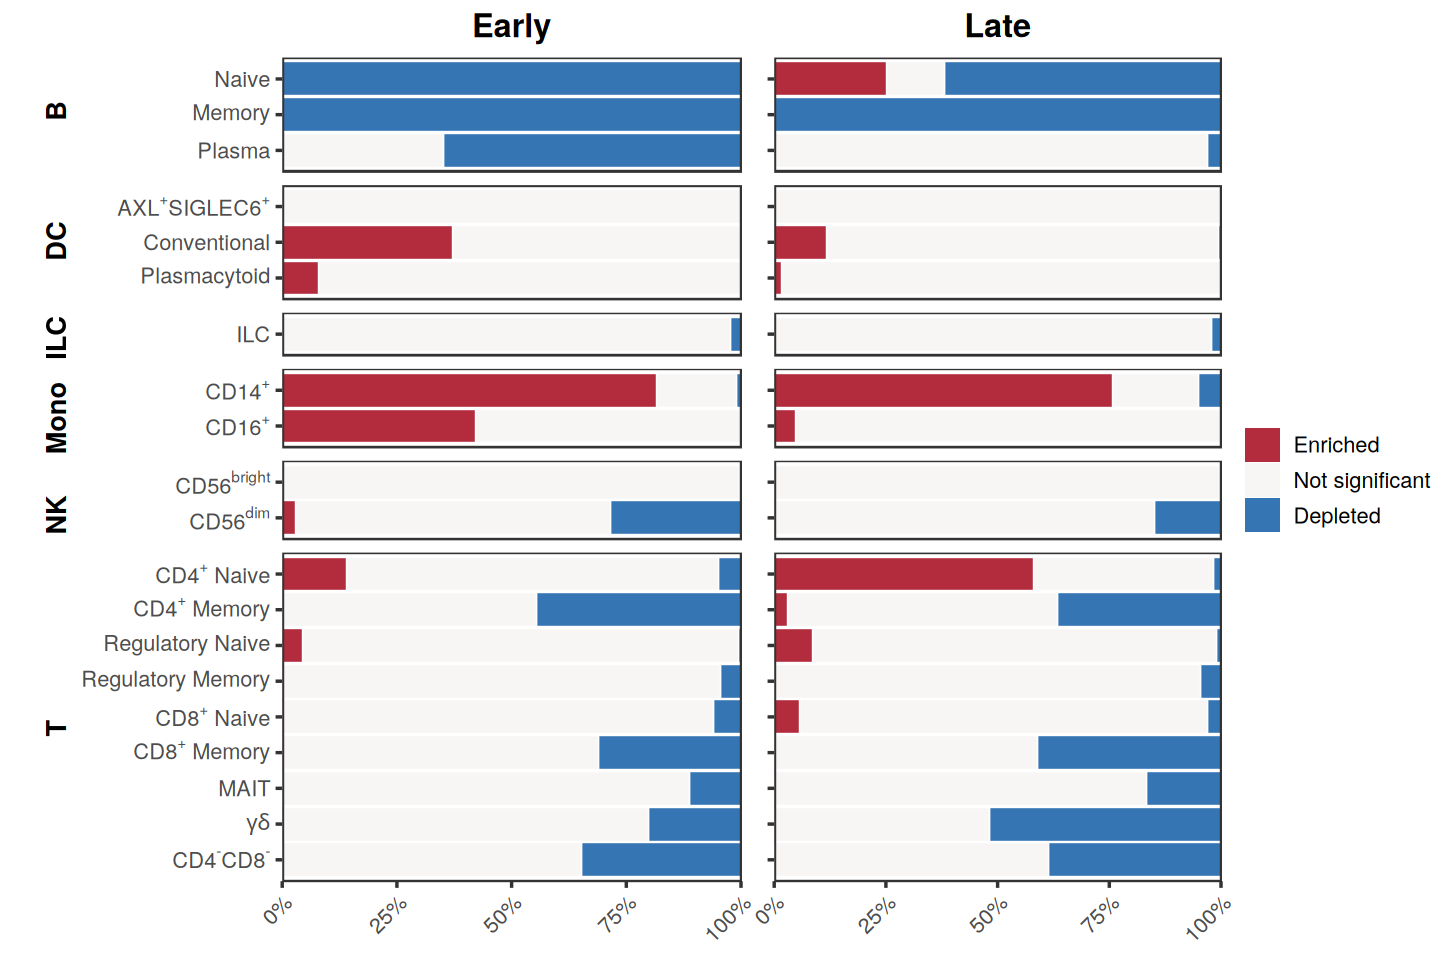

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

cond <- c("Early", "Late")
data.combined <- map_dfr(cond, function(x) {
  FetchData(seu, vars = c("cluster_main", "cluster_coarse")) %>%
    bind_cols(meld.stats[[x]]) %>%
    mutate(
      condition = x,
      perturbation = factor(
        case_when(
          z > 0 & q_adj < 1e-5 ~ "Enriched",
          z < 0 & q_adj < 1e-5 ~ "Depleted",
          TRUE ~ "No change"
        ),
        levels = c("Depleted", "No change", "Enriched")
      )
    )
}) %>%
  group_by(cluster_main, cluster_coarse, condition, perturbation) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(cluster_main, cluster_coarse, condition) %>%
  mutate(prop = count / sum(count)) %>%
  ungroup()

plots <- map(cond, function(x) {
  data.cond <- data.combined %>%
    filter(condition == x) %>%
    mutate(
      cluster_coarse = factor(
        case_match(
          cluster_coarse,
          "B_naive" ~ "Naive",
          "B_memory" ~ "Memory",
          "B_plasma" ~ "Plasma",
          "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
          "DC_conventional" ~ "Conventional",
          "DC_plasmacytoid" ~ "Plasmacytoid",
          "ILC" ~ "ILC",
          "Mono_CD14" ~ "CD14^'+'",
          "Mono_CD16" ~ "CD16^'+'",
          "NK_CD56bright" ~ "CD56^bright",
          "NK_CD56dim" ~ "CD56^dim",
          "T_CD4_naive" ~ "CD4^'+'~Naive",
          "T_CD4_memory" ~ "CD4^'+'~Memory",
          "T_regulatory_naive" ~ "Regulatory~Naive",
          "T_regulatory_memory" ~ "Regulatory~Memory",
          "T_CD8_naive" ~ "CD8^'+'~Naive",
          "T_CD8_memory" ~ "CD8^'+'~Memory",
          "T_MAIT" ~ "MAIT",
          "T_GD" ~ "gamma*delta",
          "T_DN" ~ "CD4^'-'*CD8^'-'"
        ),
        levels = c(
          "Naive", "Memory", "Plasma",
          "AXL^'+'*SIGLEC6^'+'", "Conventional", "Plasmacytoid",
          "ILC",
          "CD14^'+'", "CD16^'+'",
          "CD56^bright", "CD56^dim",
          "CD4^'+'~Naive", "CD4^'+'~Memory", "Regulatory~Naive", "Regulatory~Memory",
          "CD8^'+'~Naive", "CD8^'+'~Memory", "MAIT", "gamma*delta", "CD4^'-'*CD8^'-'"
        )
      )
    )

  ggplot(data = data.cond, mapping = aes(x = prop, y = cluster_coarse, fill = perturbation)) +
    geom_col(width = 0.95, color = "white", size = 0.3, alpha = 0.9) +
    facet_grid(rows = vars(cluster_main), scales = "free", space = "free") +
    labs(
      title = x,
      x = NULL,
      y = NULL
    ) +
    scale_x_continuous(
      labels = scales::percent_format(accuracy = 1),
      expand = expansion(mult = c(0, 0))
    ) +
    scale_y_discrete(labels = function(x) parse(text = x), limits = rev) +
    scale_fill_manual(
      values = c(
        "Depleted" = pals::brewer.rdbu(100)[90],
        "No change" = pals::brewer.rdbu(100)[50],
        "Enriched" = pals::brewer.rdbu(100)[10]
      )
    ) +
    theme_custom() +
    theme(
      strip.background = element_blank(),
      strip.text = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.text.y = if (x == "Early") element_text(hjust = 1, vjust = 0.5) else element_blank(),
      plot.title = element_text(face = "bold", hjust = 0.5),
      legend.position = "none"
    )
})

data.legend <- data.frame(
  perturbation = factor(c("Enriched", "No change", "Depleted"),
    levels = c("Enriched", "No change", "Depleted")
  ),
  y = 1
)

plot.legend <- ggplot(data.legend, aes(x = perturbation, y = y, fill = perturbation)) +
  geom_col(alpha = 0.9) +
  scale_fill_manual(
    values = c(
      "Enriched" = pals::brewer.rdbu(100)[10],
      "No change" = pals::brewer.rdbu(100)[50],
      "Depleted" = pals::brewer.rdbu(100)[90]
    ),
    labels = c("Enriched", "Not significant", "Depleted")
  ) +
  guides(fill = guide_legend(
    title = NULL,
    keywidth = unit(0.75, "cm"),
    keyheight = unit(0.75, "cm")
  )) +
  theme_custom()

legend <- ggpubr::get_legend(plot.legend)

annotation <- ggplot(data = seu[[c("cluster_main", "cluster_coarse")]] %>% distinct(), mapping = aes(y = fct_rev(cluster_coarse))) +
  facet_grid(rows = vars(cluster_main), scales = "free", space = "free") +
  theme_void() +
  theme(
    strip.text.y = element_text(size = 16, face = "bold", angle = 90),
    panel.spacing = unit(0.5, "cm")
  )

plot.combined <- plot_grid(annotation, plots[[1]], plots[[2]], legend, nrow = 1, axis = "tblr", align = "h", rel_widths = c(0.1, 1, 0.7, 0.3))

plot.combined

ggsave(
  plot = plot.combined,
  filename = "../results/plots/cohort_treatment_naive_all_perturbation_scores_bar.pdf",
  width = 12,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Session Info

In [8]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ComplexHeatmap_2.18.0 cowplot_1.1.3         patchwork_1.3.0      
 [4] ggforce_0.4.2         lubridate_1.9.3       forcats_1.0.0        
 [7] stringr_1.5.1         dplyr_1.1.4           purrr_1.0.2          
[10] readr_2.1.5           tidyr_1.3.1           tibble_3.2.1         
[13] ggplot2_3.5.1         tidyverse_2.0.0       future_1.34.0        
[16] Seurat_5.1.0          SeuratObject_5.0.2    sp_2.1-4             

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     shape_1.4.6.1          jsonlite_1.8.9      